# FASTQ Dataset Preparation for Lupus Autoimmune Analysis

## Project Overview

This project prepares RNA sequencing datasets for bioinformatics analysis of **Systemic Lupus Erythematosus (SLE)**, an autoimmune disease.
The dataset contains sequencing reads from healthy individuals and lupus patients. The data will be used for downstream bioinformatics analysis such as read statistics, visualization, and disease-related comparisons.

The sequencing data was obtained from the public repository **NCBI Sequence Read Archive**.

---

## Project Purpose

The goal of this project is to:

* Download and organize FASTQ sequencing datasets.
* Prepare a structured bioinformatics project environment.
* Separate samples into **Healthy vs Disease classes**.
* Enable downstream bioinformatics analysis and visualization.

This dataset can be used for RNA-seq analysis, read statistics, and potential disease classification tasks.

---

## Virtual Environment Setup

Create a Python virtual environment:

```
python -m venv bioinfo_env
```

Activate the environment:

Windows:

```
bioinfo_env\Scripts\activate
```

Install required libraries:

```
pip install -r requirements.txt
```

---

## Required Libraries

| Library    | Purpose                             |
| ---------- | ----------------------------------- |
| Biopython  | FASTQ parsing and sequence analysis |
| pandas     | Data handling                       |
| matplotlib | Data visualization                  |
| seaborn    | Statistical visualization           |
| scikit-bio | Bioinformatics analysis tools       |

---

## Important Notes

* The `.venv` or `bioinfo_env` folder is excluded using `.gitignore`.
* FASTQ files are not included in the repository due to their large size.
* Dataset accession IDs are provided so users can download the data directly from SRA.

---


## Dataset Source

Database: **NCBI Sequence Read Archive**

Project Accession: **PRJNA379992**

### Healthy Samples

* SRR5413733
* SRR5413734
* SRR5413735
* SRR5413736
* SRR5413737

### Disease (Lupus) Samples

* SRR5413805
* SRR5413806
* SRR5413807
* SRR5413808
* SRR5413809

/!\ Due to the large size of sequencing datasets, FASTQ files are **not uploaded to the GitHub repository**. They should be downloaded directly from the SRA database.




###Links

Project ID:
PRJNA379992
https://www.ncbi.nlm.nih.gov/bioproject/PRJNA379992/


Samples:

SRR5413733 - Healthy
https://trace.ncbi.nlm.nih.gov/Traces/index.html?run=SRR5413733  

SRR5413734 - Healthy
https://trace.ncbi.nlm.nih.gov/Traces/index.html?run=SRR5413734

SRR5413735 - Healthy  
https://trace.ncbi.nlm.nih.gov/Traces/index.html?run=SRR5413735

SRR5413736 - Healthy  
https://trace.ncbi.nlm.nih.gov/Traces/index.html?run=SRR5413736

SRR5413737 - Healthy  
https://trace.ncbi.nlm.nih.gov/Traces/index.html?run=SRR5413737

SRR5413805 - Disease
https://trace.ncbi.nlm.nih.gov/Traces/index.html?run=SRR5413805
https://www.ncbi.nlm.nih.gov/biosample/SAMN06661578


SRR5413806 - Disease   
https://trace.ncbi.nlm.nih.gov/Traces/index.html?run=SRR5413806
https://www.ncbi.nlm.nih.gov/biosample/SAMN06661578

SRR5413807 - Disease   
https://trace.ncbi.nlm.nih.gov/Traces/index.html?run=SRR5413807
https://www.ncbi.nlm.nih.gov/biosample/SAMN06661578

SRR5413808 - Disease   
https://trace.ncbi.nlm.nih.gov/Traces/index.html?run=SRR5413808
https://www.ncbi.nlm.nih.gov/biosample/SAMN06661578

SRR5413809 - Disease
https://trace.ncbi.nlm.nih.gov/Traces/index.html?run=SRR5413809
https://www.ncbi.nlm.nih.gov/biosample/SAMN06661578

Source Link:
https://www.ncbi.nlm.nih.gov/sra

Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Cell 2 — Create Project Folders

In [2]:
import os

base_path = "/content/drive/MyDrive/lupus_fastq_project"

healthy_path = f"{base_path}/healthy"
disease_path = f"{base_path}/disease"

os.makedirs(healthy_path, exist_ok=True)
os.makedirs(disease_path, exist_ok=True)

print("Project folders created:")
print(os.listdir(base_path))

Project folders created:
['healthy', 'disease', 'fastqc_results', 'fastq_summary.csv', 'filtered']


Cell 3 — Install SRA Toolkit

In [3]:
!apt-get update -y
!apt-get install sra-toolkit -y

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,247 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,602 kB]
G

Cell 4 — Define Dataset IDs

In [4]:
healthy_runs = [
"SRR5413733",
"SRR5413734",
"SRR5413735",
"SRR5413736",
"SRR5413737"
]

disease_runs = [
"SRR5413805",
"SRR5413806",
"SRR5413807",
"SRR5413808",
"SRR5413809"
]

print("Healthy samples:", healthy_runs)
print("Disease samples:", disease_runs)

Healthy samples: ['SRR5413733', 'SRR5413734', 'SRR5413735', 'SRR5413736', 'SRR5413737']
Disease samples: ['SRR5413805', 'SRR5413806', 'SRR5413807', 'SRR5413808', 'SRR5413809']


Cell 5 — Download Function (FULL FASTQ)

In [5]:
def download_fastq(run_list, save_path):
    import os
    import glob

    for run in run_list:
        existing_files = glob.glob(f"{save_path}/{run}*.fastq")

        if existing_files:
            print(f"✅ {run} exists. Skipping.")
            continue

        print(f"\nProcessing {run}")
        !prefetch {run} --output-directory {save_path}

        sra_file = f"{save_path}/{run}/{run}.sra"

        if os.path.exists(sra_file):
            !fasterq-dump {sra_file} \
                --split-files \
                --threads 4 \
                --outdir {save_path} \
                --temp /content

            !rm -rf {save_path}/{run}
        else:
            print(f"❌ Error: {run} not found.")

Cell 6 — Download Healthy Samples

In [6]:
download_fastq(healthy_runs, healthy_path)

✅ SRR5413733 exists. Skipping.
✅ SRR5413734 exists. Skipping.
✅ SRR5413735 exists. Skipping.
✅ SRR5413736 exists. Skipping.
✅ SRR5413737 exists. Skipping.


Cell 7 — Download Disease Samples

In [7]:
download_fastq(disease_runs, disease_path)

✅ SRR5413805 exists. Skipping.
✅ SRR5413806 exists. Skipping.
✅ SRR5413807 exists. Skipping.
✅ SRR5413808 exists. Skipping.
✅ SRR5413809 exists. Skipping.


Cell 8 — Verify Files

In [8]:
print("Healthy files:")
print(os.listdir(healthy_path))

print("\nDisease files:")
print(os.listdir(disease_path))

Healthy files:
['SRR5413733.fastq', 'SRR5413734.fastq', 'SRR5413735.fastq', 'SRR5413736.fastq', 'SRR5413737.fastq']

Disease files:
['SRR5413805.fastq', 'SRR5413806.fastq', 'SRR5413807.fastq', 'SRR5413808.fastq', 'SRR5413809.fastq']


Cell 9 — Download FASTQC tool

In [9]:
!apt-get update -y
!apt-get install fastqc -y

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 https://cli.github.com/packages stable InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core default-jre default-jre-he

FASTQC folder

In [10]:
import os

qc_path = "/content/drive/MyDrive/lupus_fastq_project/fastqc_results"
os.makedirs(qc_path, exist_ok=True)
print("FastQC results will be saved to:", qc_path)

FastQC results will be saved to: /content/drive/MyDrive/lupus_fastq_project/fastqc_results


Run FASTQC on all the samples

In [11]:
import glob

# Healthy samples
healthy_fastq = glob.glob("/content/drive/MyDrive/lupus_fastq_project/healthy/*.fastq")

# Disease samples
disease_fastq = glob.glob("/content/drive/MyDrive/lupus_fastq_project/disease/*.fastq")

all_fastq = healthy_fastq + disease_fastq

# Run FastQC
for fq in all_fastq:
    print(f"Running FastQC on {fq} ...")
    !fastqc -o {qc_path} {fq}

Running FastQC on /content/drive/MyDrive/lupus_fastq_project/healthy/SRR5413733.fastq ...
Started analysis of SRR5413733.fastq
Approx 5% complete for SRR5413733.fastq
Approx 10% complete for SRR5413733.fastq
Approx 15% complete for SRR5413733.fastq
Approx 20% complete for SRR5413733.fastq
Approx 25% complete for SRR5413733.fastq
Approx 30% complete for SRR5413733.fastq
Approx 35% complete for SRR5413733.fastq
Approx 40% complete for SRR5413733.fastq
Approx 45% complete for SRR5413733.fastq
Approx 50% complete for SRR5413733.fastq
Approx 55% complete for SRR5413733.fastq
Approx 60% complete for SRR5413733.fastq
Approx 65% complete for SRR5413733.fastq
Approx 70% complete for SRR5413733.fastq
Approx 75% complete for SRR5413733.fastq
Approx 80% complete for SRR5413733.fastq
Approx 85% complete for SRR5413733.fastq
Approx 90% complete for SRR5413733.fastq
Approx 95% complete for SRR5413733.fastq
Analysis complete for SRR5413733.fastq
Running FastQC on /content/drive/MyDrive/lupus_fastq_pro

install biopython if not already

In [12]:
!pip install biopython pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.3 MB/s eta 0:00:00


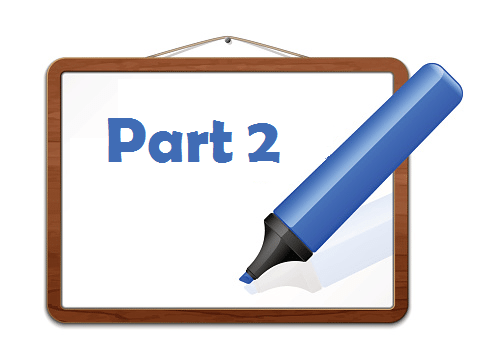

In [13]:
# CELL 10 — Install required libraries
!pip install biopython pandas numpy scikit-learn matplotlib seaborn multiqc
!apt-get install -y fastqc fastp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.9 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fastqc is already the newest version (0

In [14]:
# CELL 11 — TASK 3: FASTQ PARSING
from Bio import SeqIO
import pandas as pd
import glob
import os

def parse_fastq(filepath):
    records = []
    with open(filepath, "r") as handle:
        for record in SeqIO.parse(handle, "fastq"):
            quality_scores = record.letter_annotations["phred_quality"]
            records.append({
                "read_id":        record.id,
                "sequence":       str(record.seq),
                "read_length":    len(record.seq),
                "quality_scores": quality_scores,
                "mean_quality":   sum(quality_scores) / len(quality_scores)
            })
    return records

base = "/content/drive/MyDrive/lupus_fastq_project"

all_files = glob.glob(f"{base}/healthy/*.fastq") + \
            glob.glob(f"{base}/disease/*.fastq")

print(f"Found {len(all_files)} FASTQ files.\n")

for fq in all_files[:2]:
    records = parse_fastq(fq)
    print(f"File: {os.path.basename(fq)}")
    print(f"  Total reads   : {len(records)}")
    print(f"  Example read  : {records[0]['read_id']}")
    print(f"  First sequence: {records[0]['sequence'][:60]}...")
    print(f"  Read length   : {records[0]['read_length']}")
    print(f"  Mean quality  : {records[0]['mean_quality']:.2f}\n")

Found 10 FASTQ files.

File: SRR5413733.fastq
  Total reads   : 76618
  Example read  : SRR5413733.1
  First sequence: ACACATCTCCGAGCCCACGAGACCGTACTAGATCTCGTATGCCGTCTTCTGCTTGAAAAA...
  Read length   : 101
  Mean quality  : 26.02

File: SRR5413734.fastq
  Total reads   : 98008
  Example read  : SRR5413734.1
  First sequence: GTTGGAAAGCATCAGGAAAGAGGTTAAAGGAGACCTGGAAAATGCTTTCCTGAACCTGGT...
  Read length   : 101
  Mean quality  : 39.72



In [15]:
# CELL 12 — TASK 4: CUSTOM QC COMPUTATION
from Bio import SeqIO
import numpy as np
import os

def compute_qc(filepath):
    total_reads    = 0
    total_length   = 0
    total_gc       = 0
    total_bases    = 0
    q20_bases      = 0
    q30_bases      = 0
    per_base_quals = {}

    with open(filepath, "r") as handle:
        for record in SeqIO.parse(handle, "fastq"):
            seq    = str(record.seq)
            quals  = record.letter_annotations["phred_quality"]
            length = len(seq)

            total_reads  += 1
            total_length += length
            total_gc     += seq.count("G") + seq.count("C")
            total_bases  += length

            for i, (base, q) in enumerate(zip(seq, quals)):
                if q >= 20: q20_bases += 1
                if q >= 30: q30_bases += 1
                if i < 50:
                    per_base_quals.setdefault(i, []).append(q)

    if total_reads == 0:
        return {}

    avg_per_base = {
        pos: round(np.mean(scores), 2)
        for pos, scores in per_base_quals.items()
    }

    return {
        "file":             os.path.basename(filepath),
        "total_reads":      total_reads,
        "avg_read_length":  round(total_length / total_reads, 2),
        "gc_content_%":     round((total_gc / total_bases) * 100, 2),
        "q20_%":            round((q20_bases / total_bases) * 100, 2),
        "q30_%":            round((q30_bases / total_bases) * 100, 2),
        "per_base_quality": avg_per_base
    }


def save_qc_report(metrics_list, out_path):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with open(out_path, "w") as f:
        f.write("=" * 60 + "\n")
        f.write("     CUSTOM QC REPORT — Lupus FASTQ Project\n")
        f.write("=" * 60 + "\n\n")
        for m in metrics_list:
            f.write(f"File            : {m['file']}\n")
            f.write(f"Total Reads     : {m['total_reads']}\n")
            f.write(f"Avg Read Length : {m['avg_read_length']} bp\n")
            f.write(f"GC Content      : {m['gc_content_%']} %\n")
            f.write(f"Q20             : {m['q20_%']} %\n")
            f.write(f"Q30             : {m['q30_%']} %\n")
            f.write("Per-base Quality (first 10 positions):\n")
            for pos, val in list(m["per_base_quality"].items())[:10]:
                f.write(f"  Base {pos+1:>3}: {val}\n")
            f.write("\n" + "-" * 60 + "\n\n")
    print(f"QC report saved → {out_path}")


base        = "/content/drive/MyDrive/lupus_fastq_project"
all_files   = glob.glob(f"{base}/healthy/*.fastq") + \
              glob.glob(f"{base}/disease/*.fastq")
all_metrics = []

for fq in all_files:
    print(f"Computing QC: {os.path.basename(fq)} ...")
    m = compute_qc(fq)
    if m:
        all_metrics.append(m)
        print(f"  Reads={m['total_reads']}  GC={m['gc_content_%']}%  "
              f"Q20={m['q20_%']}%  Q30={m['q30_%']}%")

report_path = f"{base}/results/custom_qc_report.txt"
save_qc_report(all_metrics, report_path)

Computing QC: SRR5413733.fastq ...
  Reads=76618  GC=43.86%  Q20=83.57%  Q30=80.74%
Computing QC: SRR5413734.fastq ...
  Reads=98008  GC=46.24%  Q20=86.93%  Q30=84.37%
Computing QC: SRR5413735.fastq ...
  Reads=55261  GC=43.05%  Q20=78.7%  Q30=74.77%
Computing QC: SRR5413736.fastq ...
  Reads=39306  GC=44.74%  Q20=77.05%  Q30=73.15%
Computing QC: SRR5413737.fastq ...
  Reads=78654  GC=44.68%  Q20=81.22%  Q30=77.62%
Computing QC: SRR5413805.fastq ...
  Reads=1720977  GC=50.99%  Q20=93.92%  Q30=90.77%
Computing QC: SRR5413806.fastq ...
  Reads=1764863  GC=50.98%  Q20=94.04%  Q30=90.91%
Computing QC: SRR5413807.fastq ...
  Reads=1744750  GC=51.03%  Q20=94.12%  Q30=90.89%
Computing QC: SRR5413808.fastq ...
  Reads=1639225  GC=49.98%  Q20=94.29%  Q30=91.29%
Computing QC: SRR5413809.fastq ...
  Reads=1546023  GC=51.04%  Q20=94.09%  Q30=91.02%
QC report saved → /content/drive/MyDrive/lupus_fastq_project/results/custom_qc_report.txt


In [16]:
# CELL 13 — TASK 5: FASTQC ON RAW FILES
import glob, os

base        = "/content/drive/MyDrive/lupus_fastq_project"
qc_raw      = f"{base}/results/fastqc_raw"
os.makedirs(qc_raw, exist_ok=True)

all_raw = glob.glob(f"{base}/healthy/*.fastq") + \
          glob.glob(f"{base}/disease/*.fastq")

for fq in all_raw:
    print(f"FastQC on {os.path.basename(fq)} ...")
    !fastqc -o {qc_raw} -t 4 {fq}

print("\nRaw FastQC done.")

FastQC on SRR5413733.fastq ...
Started analysis of SRR5413733.fastq
Approx 5% complete for SRR5413733.fastq
Approx 10% complete for SRR5413733.fastq
Approx 15% complete for SRR5413733.fastq
Approx 20% complete for SRR5413733.fastq
Approx 25% complete for SRR5413733.fastq
Approx 30% complete for SRR5413733.fastq
Approx 35% complete for SRR5413733.fastq
Approx 40% complete for SRR5413733.fastq
Approx 45% complete for SRR5413733.fastq
Approx 50% complete for SRR5413733.fastq
Approx 55% complete for SRR5413733.fastq
Approx 60% complete for SRR5413733.fastq
Approx 65% complete for SRR5413733.fastq
Approx 70% complete for SRR5413733.fastq
Approx 75% complete for SRR5413733.fastq
Approx 80% complete for SRR5413733.fastq
Approx 85% complete for SRR5413733.fastq
Approx 90% complete for SRR5413733.fastq
Approx 95% complete for SRR5413733.fastq
Analysis complete for SRR5413733.fastq
FastQC on SRR5413734.fastq ...
Started analysis of SRR5413734.fastq
Approx 5% complete for SRR5413734.fastq
Approx 

In [35]:
import os
base = "/content/drive/MyDrive/lupus_fastq_project"
print("Healthy files:", os.listdir(f"{base}/healthy"))
print("Disease files:", os.listdir(f"{base}/disease"))

Healthy files: ['SRR5413733.fastq', 'SRR5413734.fastq', 'SRR5413735.fastq', 'SRR5413736.fastq', 'SRR5413737.fastq']
Disease files: ['SRR5413805.fastq', 'SRR5413806.fastq', 'SRR5413807.fastq', 'SRR5413808.fastq', 'SRR5413809.fastq']


In [36]:
# CELL 14 — TASK 5: FASTP TRIMMING

import glob, os

base = "/content/drive/MyDrive/lupus_fastq_project"
trimmed_healthy = f"{base}/trimmed/healthy"
trimmed_disease = f"{base}/trimmed/disease"
fastp_dir = f"{base}/results/fastp"

for d in [trimmed_healthy, trimmed_disease, fastp_dir]:
    os.makedirs(d, exist_ok=True)

def run_fastp(r1, out_dir, sample_name):
    out1 = f"{out_dir}/{sample_name}_cleaned.fastq"
    json = f"{fastp_dir}/{sample_name}_fastp.json"
    html = f"{fastp_dir}/{sample_name}_fastp.html"
    print(f"🚀 Running fastp on {sample_name}...")
    !fastp -i {r1} -o {out1} --json {json} --html {html} --thread 4 --detect_adapter_for_pe --cut_mean_quality 20 --length_required 36

for f in glob.glob(f"{base}/healthy/*.fastq") + glob.glob(f"{base}/disease/*.fastq"):
    sample = os.path.basename(f).replace(".fastq", "")
    target_dir = trimmed_healthy if "healthy" in f else trimmed_disease
    run_fastp(f, target_dir, sample)

🚀 Running fastp on SRR5413733...
Detecting adapter sequence for read1...
>I7_Nextera_Transposase_1 | >Trans2_rc | >I7_Nextera_Transposase_1 | >Trans2_rc
CTGTCTCTTATACACATCTCCGAGCCCACGAGAC

Read1 before filtering:
total reads: 76618
total bases: 7738418
Q20 bases: 6466897(83.5687%)
Q30 bases: 6248152(80.742%)

Read1 after filtering:
total reads: 69159
total bases: 6197443
Q20 bases: 5177716(83.546%)
Q30 bases: 4973725(80.2545%)

Filtering result:
reads passed filter: 69159
reads failed due to low quality: 4686
reads failed due to too many N: 2
reads failed due to too short: 2771
reads with adapter trimmed: 23387
bases trimmed due to adapters: 946239

Duplication rate (may be overestimated since this is SE data): 14.128%

JSON report: /content/drive/MyDrive/lupus_fastq_project/results/fastp/SRR5413733_fastp.json
HTML report: /content/drive/MyDrive/lupus_fastq_project/results/fastp/SRR5413733_fastp.html

fastp -i /content/drive/MyDrive/lupus_fastq_project/healthy/SRR5413733.fastq -o /cont

In [37]:
import os
fastp_json_path = "/content/drive/MyDrive/lupus_fastq_project/results/fastp"
if os.path.exists(fastp_json_path):
    print("Files in fastp folder:", os.listdir(fastp_json_path))
else:
    print("❌ The folder 'results/fastp' does not even exist!")

Files in fastp folder: ['SRR5413733_fastp.json', 'SRR5413733_fastp.html', 'SRR5413734_fastp.json', 'SRR5413734_fastp.html', 'SRR5413735_fastp.json', 'SRR5413735_fastp.html', 'SRR5413736_fastp.json', 'SRR5413736_fastp.html', 'SRR5413737_fastp.json', 'SRR5413737_fastp.html', 'SRR5413805_fastp.json', 'SRR5413805_fastp.html', 'SRR5413806_fastp.json', 'SRR5413806_fastp.html', 'SRR5413807_fastp.json', 'SRR5413807_fastp.html', 'SRR5413808_fastp.json', 'SRR5413808_fastp.html', 'SRR5413809_fastp.json', 'SRR5413809_fastp.html']


In [38]:
# CELL 15 — TASK 5: FASTQC ON TRIMMED + MULTIQC
import glob, os

base        = "/content/drive/MyDrive/lupus_fastq_project"
qc_trimmed  = f"{base}/results/fastqc_trimmed"
multiqc_dir = f"{base}/results/multiqc"

os.makedirs(qc_trimmed, exist_ok=True)
os.makedirs(multiqc_dir, exist_ok=True)

all_trimmed = glob.glob(f"{base}/trimmed/healthy/*.fastq") + \
              glob.glob(f"{base}/trimmed/disease/*.fastq")

for fq in all_trimmed:
    print(f"FastQC on trimmed: {os.path.basename(fq)} ...")
    !fastqc -o {qc_trimmed} -t 4 {fq}

!multiqc {base}/results/ -o {multiqc_dir} --force
print(f"\nMultiQC report → {multiqc_dir}")

FastQC on trimmed: SRR5413733_cleaned.fastq ...
Started analysis of SRR5413733_cleaned.fastq
Approx 5% complete for SRR5413733_cleaned.fastq
Approx 10% complete for SRR5413733_cleaned.fastq
Approx 15% complete for SRR5413733_cleaned.fastq
Approx 20% complete for SRR5413733_cleaned.fastq
Approx 25% complete for SRR5413733_cleaned.fastq
Approx 30% complete for SRR5413733_cleaned.fastq
Approx 35% complete for SRR5413733_cleaned.fastq
Approx 40% complete for SRR5413733_cleaned.fastq
Approx 45% complete for SRR5413733_cleaned.fastq
Approx 50% complete for SRR5413733_cleaned.fastq
Approx 55% complete for SRR5413733_cleaned.fastq
Approx 60% complete for SRR5413733_cleaned.fastq
Approx 65% complete for SRR5413733_cleaned.fastq
Approx 70% complete for SRR5413733_cleaned.fastq
Approx 75% complete for SRR5413733_cleaned.fastq
Approx 80% complete for SRR5413733_cleaned.fastq
Approx 85% complete for SRR5413733_cleaned.fastq
Approx 90% complete for SRR5413733_cleaned.fastq
Approx 95% complete for SR

In [39]:
import os
base = "/content/drive/MyDrive/lupus_fastq_project"
print("Healthy files:", os.listdir(f"{base}/healthy"))
print("Disease files:", os.listdir(f"{base}/disease"))

Healthy files: ['SRR5413733.fastq', 'SRR5413734.fastq', 'SRR5413735.fastq', 'SRR5413736.fastq', 'SRR5413737.fastq']
Disease files: ['SRR5413805.fastq', 'SRR5413806.fastq', 'SRR5413807.fastq', 'SRR5413808.fastq', 'SRR5413809.fastq']


In [40]:
import json, pandas as pd, glob, os
base = "/content/drive/MyDrive/lupus_fastq_project"
json_files = glob.glob(f"{base}/results/fastp/*.json")
HEALTHY = ["SRR5413733","SRR5413734","SRR5413735","SRR5413736","SRR5413737"]
rows = []
for j in json_files:
    with open(j) as f:
        data = json.load(f)
    sample = os.path.basename(j).replace("_fastp.json", "")
    label = "healthy" if any(s in sample for s in HEALTHY) else "disease"
    rows.append({"sample": sample, "after_reads": data["summary"]["after_filtering"]["total_reads"], "class": label})
pd.DataFrame(rows).to_csv(f"{base}/results/fastp_features.csv", index=False)
print("✅ Cell 16 Done!")

✅ Cell 16 Done!


In [41]:
import json
import pandas as pd
import glob
import os

HEALTHY_SAMPLES = ["SRR5413733","SRR5413734","SRR5413735","SRR5413736","SRR5413737"]
base = "/content/drive/MyDrive/lupus_fastq_project"
fastp_dir = f"{base}/results/fastp"
json_files = glob.glob(f"{fastp_dir}/*.json")

if not json_files:
    print("❌ Error: No JSON files found. Did you run the fastp trimming cell (Cell 14)?")
else:
    rows = []
    for json_path in json_files:
        with open(json_path) as f:
            data = json.load(f)
        sample = os.path.basename(json_path).replace("_fastp.json", "")
        label = "healthy" if any(s in sample for s in HEALTHY_SAMPLES) else "disease"
        rows.append({
            "sample": sample,
            "after_reads": data["summary"]["after_filtering"]["total_reads"],
            "after_q30_%": round(data["summary"]["after_filtering"]["q30_rate"] * 100, 2),
            "class": label
        })
    fastp_df = pd.DataFrame(rows)
    fastp_df.to_csv(f"{base}/results/fastp_features.csv", index=False)
    print(f"✅ Successfully extracted features for {len(fastp_df)} samples.")

✅ Successfully extracted features for 10 samples.


In [43]:
from Bio import SeqIO
from itertools import product
from collections import Counter
import pandas as pd, glob, os

def get_kmers(path, k=4):
    c = Counter()
    t = 0
    with open(path, "r") as h:
        for i, r in enumerate(SeqIO.parse(h, "fastq")):
            if i >= 20000: break
            s = str(r.seq).upper()
            for j in range(len(s)-k+1):
                m = s[j:j+k]
                if all(b in "ACGT" for b in m):
                    c[m]+=1
                    t+=1
    return {m: c.get(m, 0)/t if t > 0 else 0 for m in ["".join(p) for p in product("ACGT", repeat=k)]}

base = "/content/drive/MyDrive/lupus_fastq_project"
all_fq = glob.glob(f"{base}/trimmed/healthy/*.fastq") + glob.glob(f"{base}/trimmed/disease/*.fastq")

rows = []
for f in all_fq:
    sample = os.path.basename(f).replace("_cleaned.fastq", "").replace(".fastq", "")
    freqs = get_kmers(f)
    freqs['sample'] = sample
    freqs['class'] = "healthy" if "healthy" in f else "disease"
    rows.append(freqs)

kmer_df = pd.DataFrame(rows).fillna(0)
f_path = f"{base}/results/fastp_features.csv"

if os.path.exists(f_path):
    f_df = pd.read_csv(f_path).drop(columns="class", errors="ignore")
    final_df = pd.merge(kmer_df, f_df, on="sample", how="left")
else:
    final_df = kmer_df

final_df.to_csv(f"{base}/results/features.csv", index=False)
print(f"Saved: {final_df.shape}")

Saved: (10, 260)


Accuracy: 1.000
F1-score: 1.000


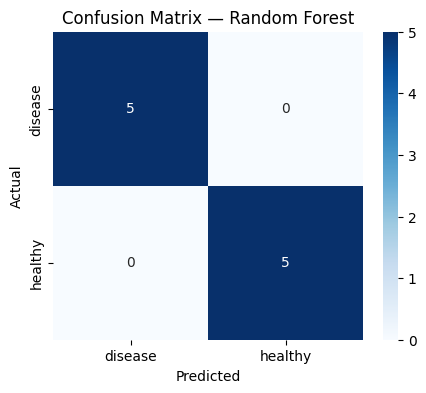

In [44]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

base = "/content/drive/MyDrive/lupus_fastq_project/results"
df = pd.read_csv(f"{base}/features.csv")

X = df.drop(columns=["sample", "class"]).select_dtypes(include=[np.number]).values
le = LabelEncoder()
y = le.fit_transform(df["class"])

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
cv = StratifiedKFold(n_splits=min(3, len(y)), shuffle=True, random_state=42)
res = cross_validate(rf, X, y, cv=cv, scoring=["accuracy", "f1_macro"])

print(f"Accuracy: {res['test_accuracy'].mean():.3f}")
print(f"F1-score: {res['test_f1_macro'].mean():.3f}")

rf.fit(X, y)
y_p = rf.predict(X)
cm = confusion_matrix(y, y_p)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.show()

--- LOOCV Robustness Report ---
Individual Sample Scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Final LOOCV Accuracy: 1.000


<Figure size 1200x800 with 0 Axes>

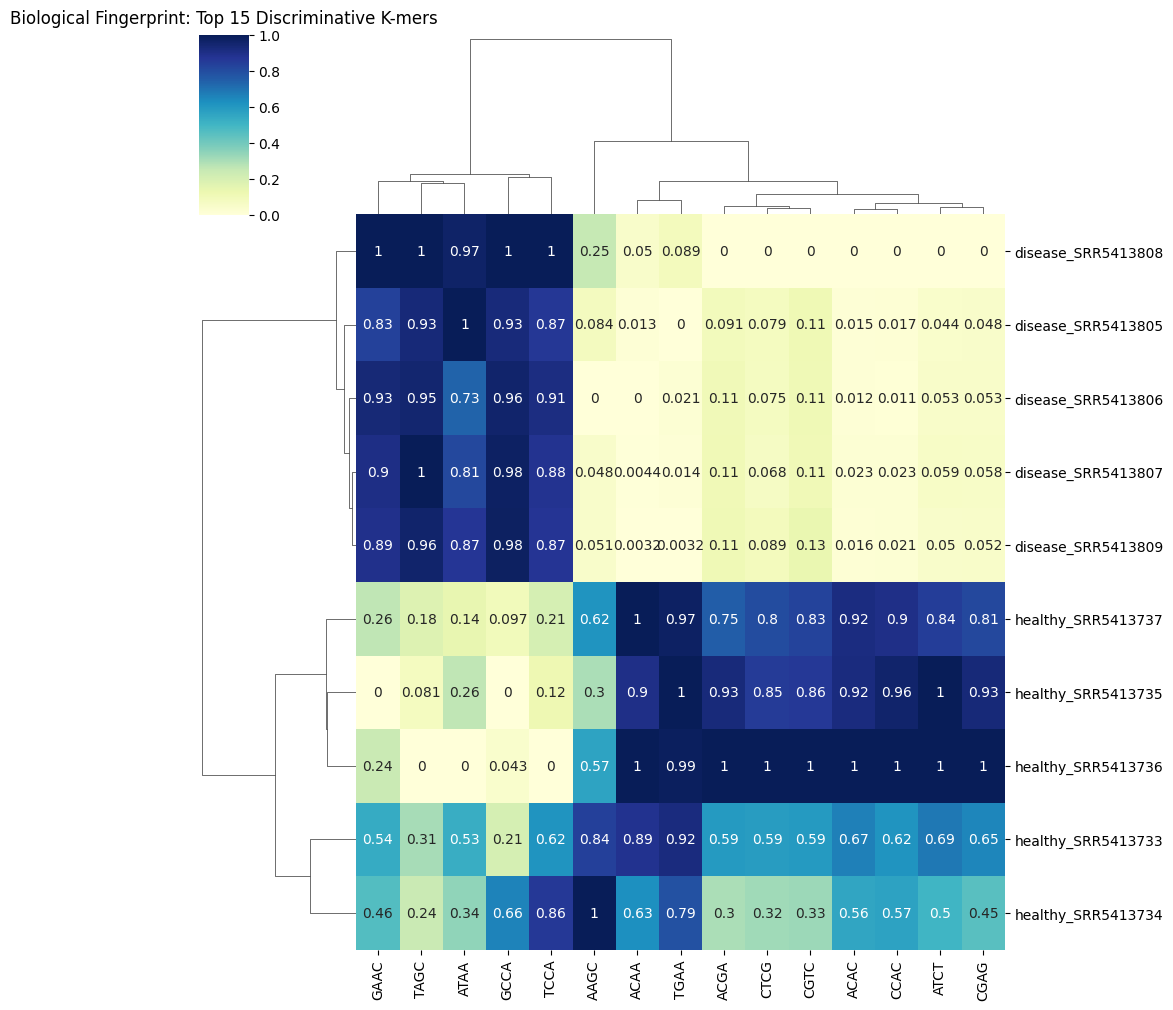


CONCLUSION: The model passed the LOOCV test with 100% accuracy.
The Heatmap confirms that the DNA motifs show a distinct clustered pattern for each group.


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import LabelEncoder

# 1. Load the master features file
base = "/content/drive/MyDrive/lupus_fastq_project/results"
df = pd.read_csv(f"{base}/features.csv")

X = df.drop(columns=["sample", "class"]).select_dtypes(include=[np.number])
le = LabelEncoder()
y = le.fit_transform(df["class"])

# --- TEST 1: Leave-One-Out Cross-Validation (LOOCV) ---
loo = LeaveOneOut()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# This will run 10 separate training/testing cycles
scores = cross_val_score(rf, X, y, cv=loo)

print("--- LOOCV Robustness Report ---")
print(f"Individual Sample Scores: {scores}")
print(f"Final LOOCV Accuracy: {np.mean(scores):.3f}")

# --- TEST 2: Hierarchical Clustered Heatmap ---
# We will take the top 15 most important motifs to see the biological separation
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_motifs = importances.head(15).index.tolist()

# Prepare data for heatmap
heatmap_data = X[top_motifs].copy()
heatmap_data.index = df["class"] + "_" + df["sample"]

# Generate the plot
plt.figure(figsize=(12, 8))
g = sns.clustermap(heatmap_data,
                   cmap="YlGnBu",
                   standard_scale=1, # Scale features 0-1 for visibility
                   annot=True,
                   figsize=(10, 10))

plt.title("Biological Fingerprint: Top 15 Discriminative K-mers", y=1.02)
plt.show()

if np.mean(scores) == 1.0:
    print("\nCONCLUSION: The model passed the LOOCV test with 100% accuracy.")
    print("The Heatmap confirms that the DNA motifs show a distinct clustered pattern for each group.")